In [1]:
import pandas as pd;
import numpy as np;
import matplotlib.pyplot as plt;
import seaborn as sns;

In [2]:
df_clean = pd.read_excel("cleaned_data.xlsx");

In [5]:
refrence_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1);
refrence_date

Timestamp('2011-12-10 12:50:00')

In [6]:
rfm_df = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (refrence_date - x.max()).days,
    'InvoiceNo':'nunique',
    'TransactionValue': 'sum'
}).reset_index();

In [7]:
rfm_df.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TransactionValue': 'Monetary'
},inplace=True);

In [8]:
print("\n --RFM features--");
rfm_df


 --RFM features--


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40
...,...,...,...,...
4333,18280,278,1,180.60
4334,18281,181,1,80.82
4335,18282,8,2,178.05
4336,18283,4,16,2045.53


In [9]:
#applying rfm scores from 1-4 using pandas qcut operations
rfm_df['R_score']=pd.qcut(rfm_df['Recency'],q=4,labels=[4,3,2,1]);
rfm_df['F_score']=pd.qcut(rfm_df['Frequency'].rank(method='first'),q=4,labels=[1,2,3,4]);
rfm_df['M_score']=pd.qcut(rfm_df['Monetary'],q=4,labels=[1,2,3,4]);


In [11]:
rfm_df['RFM_segment']=rfm_df['R_score'].astype(str) + rfm_df['F_score'].astype(str) + rfm_df['M_score'].astype(str);
rfm_df['RFM_score']=rfm_df[['R_score', 'F_score', 'M_score']].sum(axis=1);

In [14]:
print("\n --RFM table--");
print(rfm_df[['CustomerID', 'Recency', 'Frequency', 'Monetary', 'RFM_segment', 'RFM_score']].head());


 --RFM table--
   CustomerID  Recency  Frequency  Monetary RFM_segment  RFM_score
0       12346      326          1  77183.60         114          6
1       12347        2          7   4310.00         444         12
2       12348       75          4   1797.24         234          9
3       12349       19          1   1757.55         314          8
4       12350      310          1    334.40         112          4


C:\Users\User\AppData\Local\Temp\ipykernel_8512\995350414.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='RFM_score',data=rfm_df,palette='rainbow');


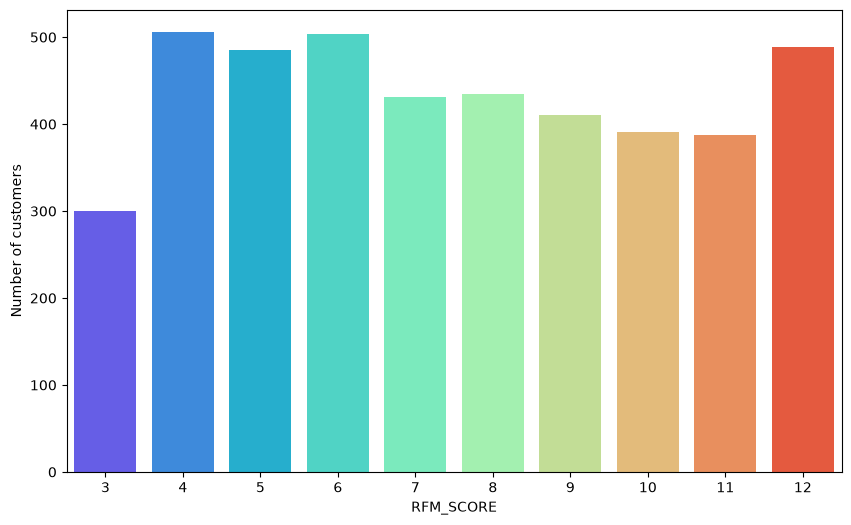

In [15]:
#visuaizing of customer groups based on rfm scores
plt.figure(figsize=(10,6));
sns.countplot(x='RFM_score',data=rfm_df,palette='rainbow');
plt.xlabel("RFM_SCORE");
plt.ylabel("Number of customers");
plt.show();

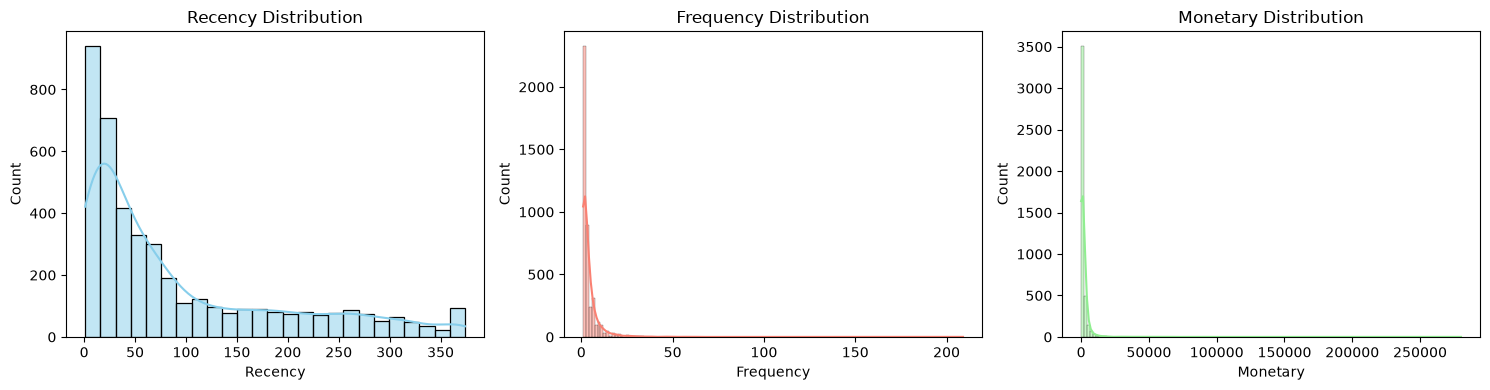

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(rfm_df['Recency'], kde=True, ax=axes[0], color='skyblue').set_title('Recency Distribution')
sns.histplot(rfm_df['Frequency'], kde=True, ax=axes[1], color='salmon').set_title('Frequency Distribution')
sns.histplot(rfm_df['Monetary'], kde=True, ax=axes[2], color='lightgreen').set_title('Monetary Distribution')
plt.tight_layout()
plt.show()

In [27]:
#feature engineering acc to docxs
customer_features = df_clean.groupby('CustomerID').agg(
    Total_Revenue=('TransactionValue', 'sum'),
    Total_Orders=('InvoiceNo', 'nunique'),
    Total_Items=('Quantity', 'sum'),
    Unique_Products=('StockCode', 'nunique'),           # Unique products purchased
    Most_Recent_Purchase=('InvoiceDate', 'max'),        # Most recent purchase date
    First_Purchase=('InvoiceDate', 'min')
).reset_index();

In [28]:
customer_features['Avg_Order_Value'] = customer_features['Total_Revenue'] / customer_features['Total_Orders']

In [29]:
customer_features['Avg_Items_Per_Order'] = customer_features['Total_Items'] / customer_features['Total_Orders']

In [30]:
customer_features['Tenure_Months']=(customer_features['Most_Recent_Purchase']-customer_features['First_Purchase']).dt.days/30
#using clip so that if persons first or last purchase is within same month then it shows feq as 1
customer_features['Tenure_Months'] = customer_features['Tenure_Months'].clip(lower=1.0)
customer_features['Purchases_Per_Month'] = customer_features['Total_Orders'] / customer_features['Tenure_Months']


In [31]:
preffered_country = df_clean.groupby('CustomerID')['Country'].agg(lambda x: x.mode()[0]).reset_index();
preffered_country.rename(columns={'Country':'Preffered_Country'},inplace=True);
customer_features = pd.merge(customer_features,preffered_country,on='CustomerID',how='left')

In [32]:
customer_features

,CustomerID,Total_Revenue,Total_Orders,Total_Items,Unique_Products,Most_Recent_Purchase,First_Purchase,Avg_Order_Value,Avg_Items_Per_Order,Tenure_Months,Purchases_Per_Month,Preffered_Country
0,12346,77183.60,1,74215,1,2011-01-18 10:01:00,2011-01-18 10:01:00,77183.600000,74215.000000,1.000000,1.000000,United Kingdom
1,12347,4310.00,7,2458,103,2011-12-07 15:52:00,2010-12-07 14:57:00,615.714286,351.142857,12.166667,0.575342,Iceland
2,12348,1797.24,4,2341,22,2011-09-25 13:13:00,2010-12-16 19:09:00,449.310000,585.250000,9.400000,0.425532,Finland
3,12349,1757.55,1,631,73,2011-11-21 09:51:00,2011-11-21 09:51:00,1757.550000,631.000000,1.000000,1.000000,Italy
4,12350,334.40,1,197,17,2011-02-02 16:01:00,2011-02-02 16:01:00,334.400000,197.000000,1.000000,1.000000,Norway
...,...,...,...,...,...,...,...,...,...,...,...,...
4333,18280,180.60,1,45,10,2011-03-07 09:52:00,2011-03-07 09:52:00,180.600000,45.000000,1.000000,1.000000,United Kingdom
4334,18281,80.82,1,54,7,2011-06-12 10:53:00,2011-06-12 10:53:00,80.820000,54.000000,1.000000,1.000000,United Kingdom
4335,18282,178.05,2,103,12,2011-12-02 11:43:00,2011-08-05 13:35:00,89.025000,51.500000,3.933333,0.508475,United Kingdom
4336,18283,2045.53,16,1357,263,2011-12-06 12:02:00,2011-01-06 14:14:00,127.845625,84.812500,11.100000,1.441441,United Kingdom


In [33]:
#product diversity is unique prodcts/quantity
customer_features['Product_Diversity_Ratio'] = customer_features['Unique_Products'] / customer_features['Total_Items']

In [34]:
cancellations_df = pd.read_excel('Cancellations.xlsx');

In [35]:
cancel_counts = cancellations_df.groupby('CustomerID')['InvoiceNo'].nunique().reset_index();
cancel_counts.rename(columns={'InvoiceNo':'Total_Cancellations'},inplace=True);



In [36]:
customer_features = pd.merge(customer_features,cancel_counts,on='CustomerID',how='left')
customer_features['Total_Cancellations']=customer_features['Total_Cancellations'].fillna(0);
#cancellation rate = total cancellation / (successfull orders + cancellations)
customer_features['Cancellation_rate']=customer_features['Total_Cancellations']/(customer_features['Total_Orders']+customer_features['Total_Cancellations']);


In [37]:
#dropping temporary tables
customer_features.drop(columns=['Total_Revenue','Total_Items','First_Purchase','Tenure_Months','Total_Cancellations'],inplace=True)

In [38]:
customer_features

,CustomerID,Total_Orders,Unique_Products,Most_Recent_Purchase,Avg_Order_Value,Avg_Items_Per_Order,Purchases_Per_Month,Preffered_Country,Product_Diversity_Ratio,Cancellation_rate
0,12346,1,1,2011-01-18 10:01:00,77183.600000,74215.000000,1.000000,United Kingdom,0.000013,0.500000
1,12347,7,103,2011-12-07 15:52:00,615.714286,351.142857,0.575342,Iceland,0.041904,0.000000
2,12348,4,22,2011-09-25 13:13:00,449.310000,585.250000,0.425532,Finland,0.009398,0.000000
3,12349,1,73,2011-11-21 09:51:00,1757.550000,631.000000,1.000000,Italy,0.115689,0.000000
4,12350,1,17,2011-02-02 16:01:00,334.400000,197.000000,1.000000,Norway,0.086294,0.000000
...,...,...,...,...,...,...,...,...,...,...
4333,18280,1,10,2011-03-07 09:52:00,180.600000,45.000000,1.000000,United Kingdom,0.222222,0.000000
4334,18281,1,7,2011-06-12 10:53:00,80.820000,54.000000,1.000000,United Kingdom,0.129630,0.000000
4335,18282,2,12,2011-12-02 11:43:00,89.025000,51.500000,0.508475,United Kingdom,0.116505,0.333333
4336,18283,16,263,2011-12-06 12:02:00,127.845625,84.812500,1.441441,United Kingdom,0.193810,0.000000
